In [1]:
# dependecies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
data = pd.read_csv('/content/drive/MyDrive/cleaned_data.csv')

data = data.drop(['Unnamed: 0'], axis=1)

data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,admission_flag,department_referral
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,False,No referral.
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,True,No referral.
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,True,General Practice
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,True,General Practice
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,False,Orthopedics


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           9216 non-null   object
 1   patient_gender       9216 non-null   object
 2   patient_race         9216 non-null   object
 3   patient_age          9216 non-null   int64 
 4   admission_day        9216 non-null   object
 5   admission_time       9216 non-null   object
 6   patient_waittime     9216 non-null   int64 
 7   admission_flag       9216 non-null   bool  
 8   department_referral  9216 non-null   object
dtypes: bool(1), int64(2), object(6)
memory usage: 585.1+ KB


In [8]:
data.describe()

,patient_age,patient_waittime
count,9216.000000,9216.000000
mean,39.855143,35.259874
std,22.755125,14.735323
min,1.000000,10.000000
25%,20.000000,23.000000
50%,39.000000,35.000000
75%,60.000000,48.000000
max,79.000000,60.000000


In [9]:
data.isnull().sum()

,0
patient_id,0
patient_gender,0
patient_race,0
patient_age,0
admission_day,0
admission_time,0
patient_waittime,0
admission_flag,0
department_referral,0


In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data.shape

(9216, 9)

In [12]:
import seaborn as sns
from matplotlib.colors import ListedColormap 

In [13]:
# for all my plots
palette = ['#EAD3A9', '#84592B', '#A05135', '#743015', '#462D1B', '#9D9368']
customcmap = ListedColormap(palette)

/tmp/ipykernel_3221/4178021792.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x700 with 0 Axes>

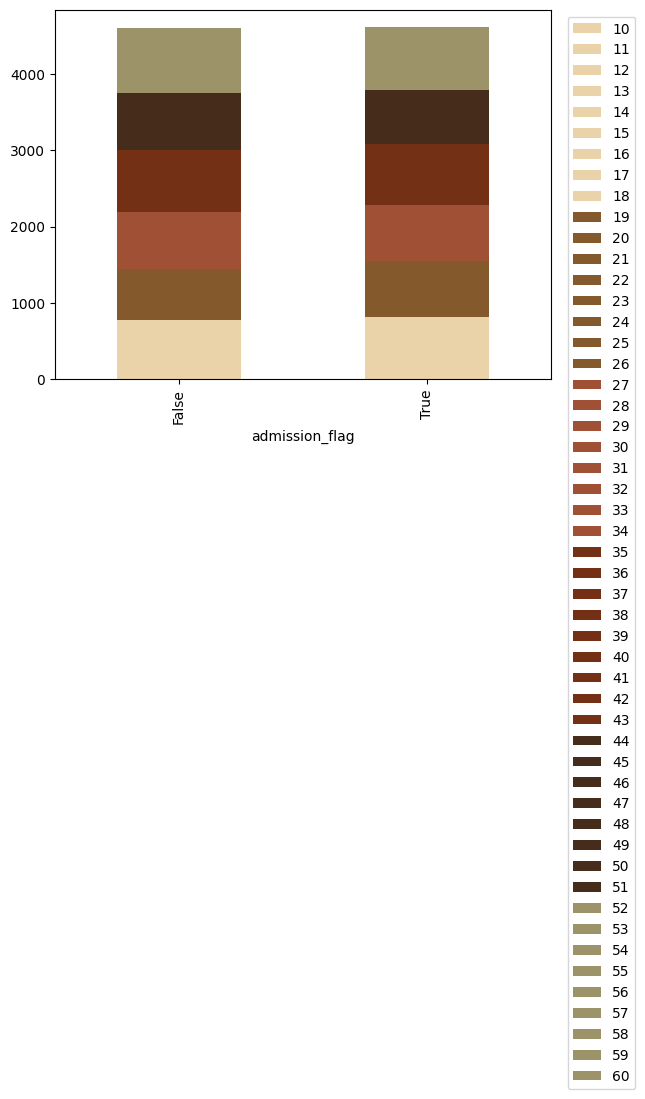

In [14]:
# creating cross table to evaluate if admission is a valuable variable
crosstab01 = pd.crosstab(data['admission_flag'], data['patient_waittime'])

plt.figure(figsize=(12, 7))
crosstab01.plot(kind='bar', stacked=True, colormap=customcmap)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [15]:
# determined by the previous images, admission_flag has inconclusive context and 
# thus need to be excluded from any further analysis or modeling.
data = data.drop(['admission_flag'], axis=1)
data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,department_referral
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,No referral.
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,No referral.
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,General Practice
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,General Practice
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,Orthopedics


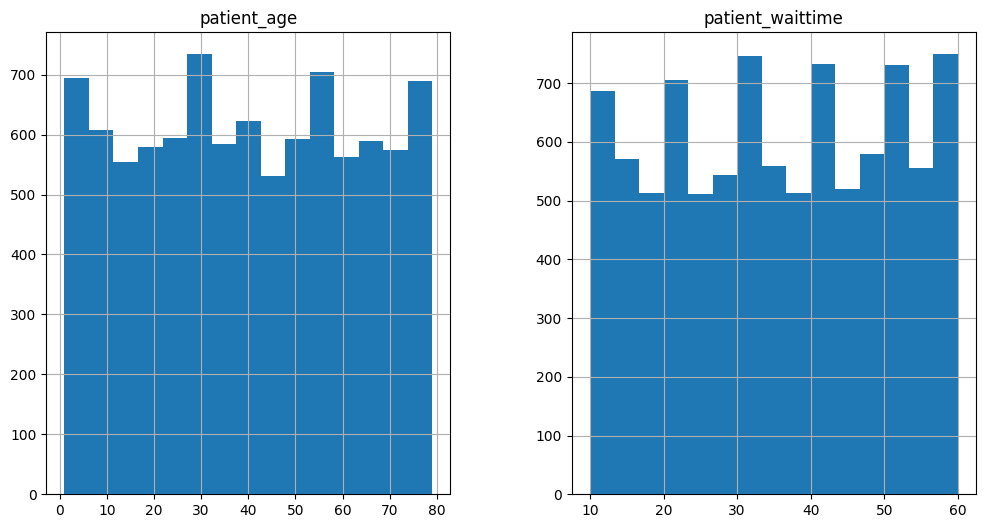

In [23]:
histogram = data.select_dtypes(include=['number', 'bool']).hist(bins=15, figsize=[12, 6])
plt.show()

In [24]:
print(data['patient_race'].unique())
print(data['department_referral'].unique())

['White' 'Native American/Alaska Native' 'African American' 'Asian'
 'Two or More Races' 'Pacific Islander' 'Declined to Identify']
['No referral.' 'General Practice' 'Orthopedics' 'Gastroenterology'
 'Physiotherapy' 'Neurology' 'Cardiology' 'Renal']


In [26]:
data['patient_race'].value_counts(normalize=True)

,proportion
patient_race,
White,0.278971
African American,0.211697
Two or More Races,0.168945
Asian,0.115017
Declined to Identify,0.111762
Pacific Islander,0.059570
Native American/Alaska Native,0.054036


In [27]:
data['department_referral'].value_counts(normalize=True)

,proportion
department_referral,
No referral.,0.585938
General Practice,0.199653
Orthopedics,0.107964
Physiotherapy,0.029948
Cardiology,0.026910
Neurology,0.020942
Gastroenterology,0.019314
Renal,0.009332


In [28]:
# this code allows me to only see the people who were referred to a department
referred = data.loc[data['department_referral'] != 'No referral.', 'department_referral']

In [30]:
referred.value_counts(normalize=True)

,proportion
department_referral,
General Practice,0.482180
Orthopedics,0.260744
Physiotherapy,0.072327
Cardiology,0.064990
Neurology,0.050577
Gastroenterology,0.046646
Renal,0.022537


<Figure size 1000x2000 with 0 Axes>

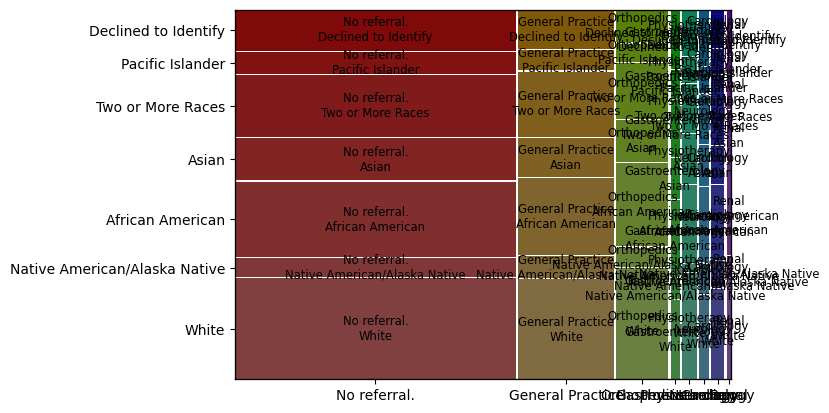

In [34]:
# ?: Is one race more likely to go to a certain department or no?
# we're using a mosiac plot to visualize the deviation of the races for each department referral
!pip3 install statsmodels
from statsmodels.graphics.mosaicplot import mosaic

plt.figure(figsize=[10,20])
mosaic(data, ['department_referral', 'patient_race'])
plt.show() 

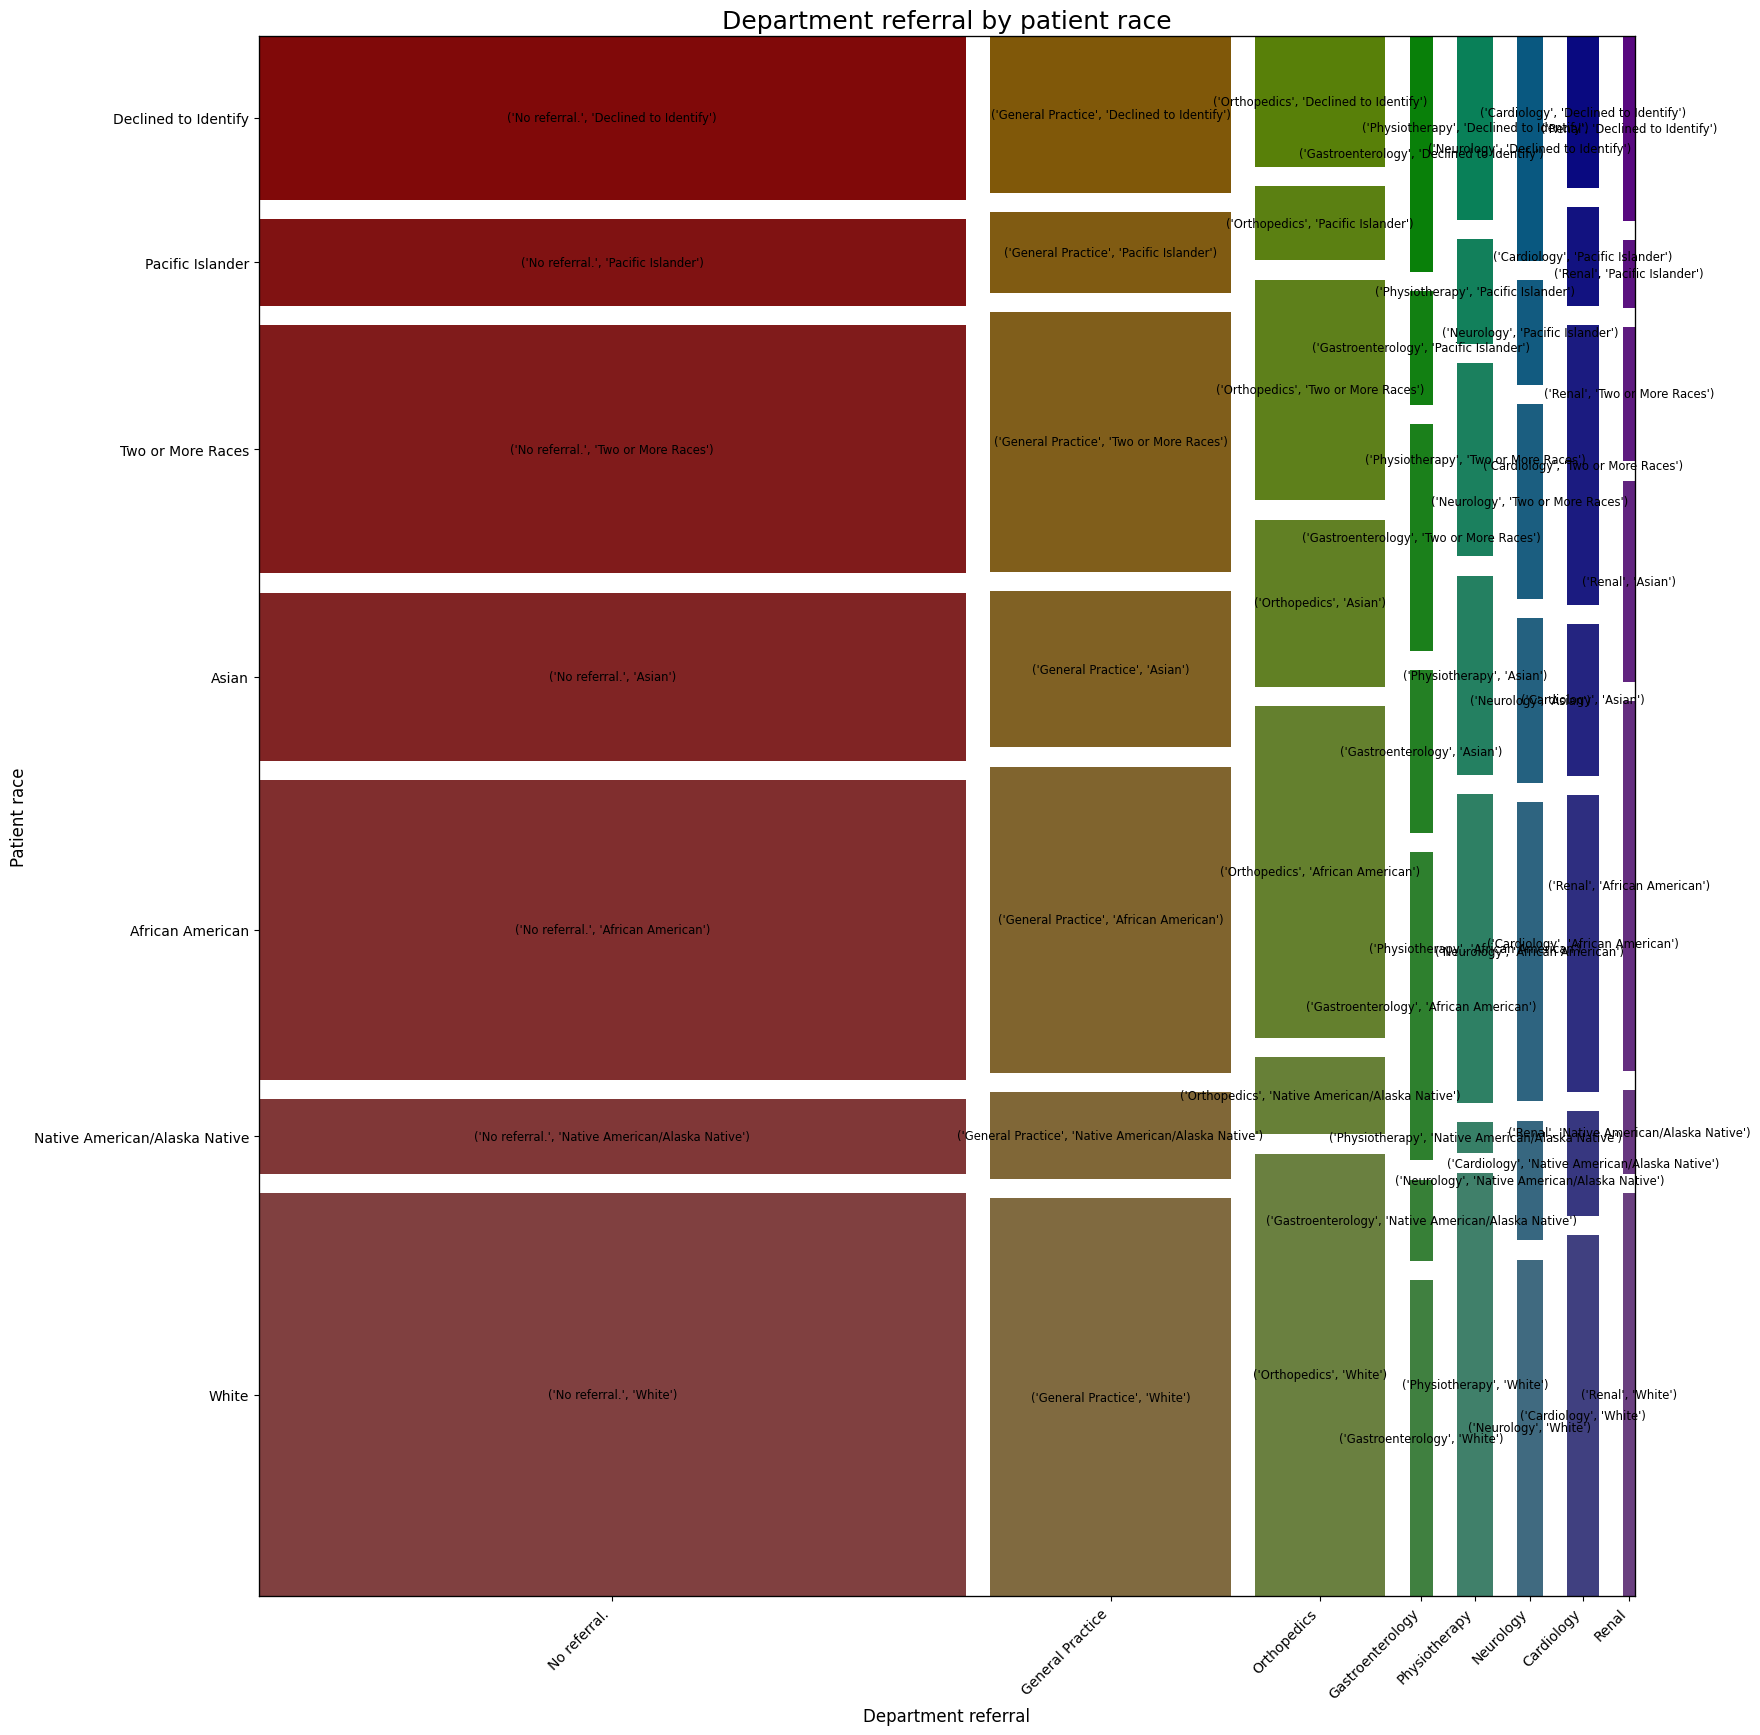

In [35]:
# Make the mosaic plot easier to read by increasing the figure size
# and adjusting spacing so long labels don't overlap.

fig, ax = plt.subplots(figsize=(16, 20))

mosaic(
    data,
    ['department_referral', 'patient_race'],
    ax=ax,
    gap=0.02,
    labelizer=lambda label: label if label is not None else ""
)

ax.set_title("Department referral by patient race", fontsize=18)
ax.set_xlabel("Department referral", fontsize=12)
ax.set_ylabel("Patient race", fontsize=12)

# Rotate long department labels so they are visible
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

# Adjust spacing around the plot
fig.tight_layout()
plt.subplots_adjust(bottom=0.18, left=0.12, right=0.98, top=0.96)

plt.show()